![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

### Amaliyot. Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/reklama_sales.csv')
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


Yuqoridagi jadvalda MohirDev MChJ tomonidan turli OAV larda (`TV`, `Radio`, `Newspaper`) berilgan reklamalar soni va mos keluvchi savdolar (`Sales`) berilgan.

Sizning vazifangiz:
1. Aynan qaysi turdagi OAVda reklama berish savdo o'sishiga ta'sir qiladi aniqlash
2. Topilgan bog'liqlik asosida Simple Linear Regression algorithmi yordamida bashorat modelini qurish.

Ushbu amaliyotda sizning vazifangiz berilgan dataset yordamida Simple Linear Regression model yaratish:
- CRISP-DM metodologiyasiga amal qiling!
- Simple linear regression qo'llash uchun 1 ta ustunni tanlab oling.

Korrelyatsiya natijalari:
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


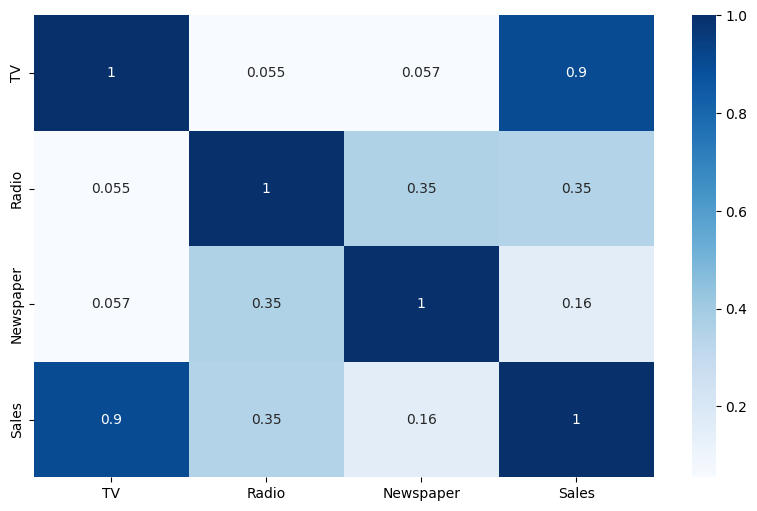

In [4]:
correlation = df.corr()
print("Korrelyatsiya natijalari:")
print(correlation['Sales'].sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['TV']].values
y = df[['Sales']].values

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

LR_model = LinearRegression()
LR_model.fit(x_train, y_train)

theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]

print(f'{theta1=}')
print(f'{theta0=}')

theta1=np.float64(0.0554829439314632)
theta0=np.float64(7.007108428241848)


MAE=1.9502948931650088
RMSE=np.float64(2.470035001123256)


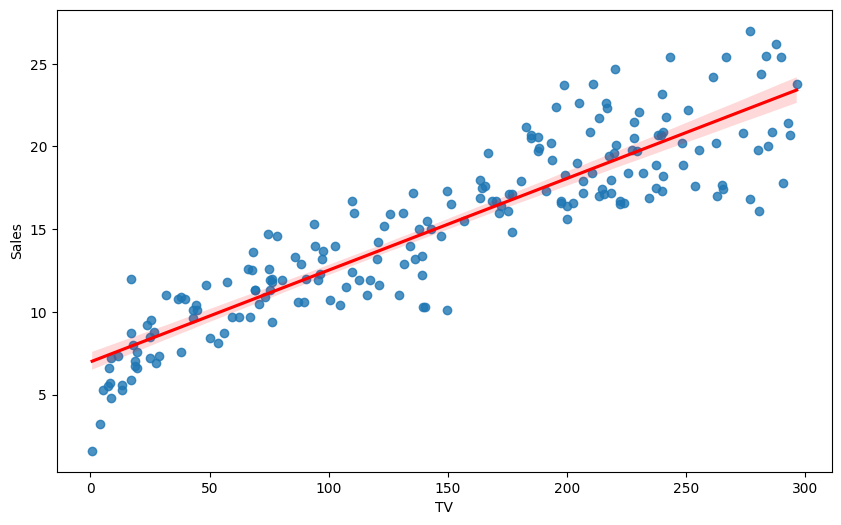

In [6]:
y_predict = LR_model.predict(x_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))

print(f"{MAE=}")
print(f"{RMSE=}")

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='TV', y='Sales', line_kws={'color':'red'})
plt.show()